# UQ Failure Analysis
---

## Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from scipy.spatial import cKDTree

from reionemu import (
    load_training_arrays,
    MCDropoutEmulator,
    predict_mc,
)

## Paths and Constants

In [2]:
h5_path = "../data/condensed_v6.h5"
fig_path = "../results/figures/base_model/"

# Base Model
ckpt_path = "../checkpoints/base_model/checkpoint.pt"
norm_path = "../checkpoints/base_model/norm/"
split_idx_path = "../checkpoints/base_model/split_idx/split_idx.npz"

In [3]:
SEED = 42

param_names = ["zmean_zre", "alpha_zre", "kb_zre", "b0_zre"]

modelcfg = {
    "input_dim": 4,
    "output_dim": 5,
    "hidden_dim": 20,
    "num_hidden_layers": 2,
    "activation": "relu",
    "dropout_rate": 0.1,
}

## Load Data

In [4]:
X, Y, ell = load_training_arrays(h5_path)

X_mean = np.load(norm_path + "X_mean.npy")
X_std = np.load(norm_path + "X_std.npy")

splits_idx = np.load(split_idx_path)
test_idx = splits_idx["test_idx"]
X_test = X[test_idx]
Y_test = Y[test_idx]

train_idx = splits_idx["train_idx"]
X_train = X[train_idx]
Y_train = Y[train_idx]

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

zmean = X[:,0]
alpha = X[:,1]
k0 = X[:,2]
b0 = X[:,3]

print(f"{len(test_idx)} Test Split Global Indices:\n{test_idx}")

200 Test Split Global Indices:
[560 481 499 323  93 843 877 763 389 397 564  32 386 364 667 453 440 640
 633 227 369 642 416 452  81 827 820 863 370 311 450  52 912 342 540 267
 721 106 122 396 992 533 730 384 105 266 347 190 864 850  39 339 188 403
 525 189 812  87 732 483   5 597 699 953 442 893 861 385 332 790 359 590
 504 962 375 114 170 851 123 301 615 602 711 786 918 508 718 599 221 654
 111 475 484 329 279 277 349 956 187  65 974 611 583 948  69 410 689 637
 177 736 982 117 586 372  10 628 927 669  63 735 500   1  42 634 529 167
 809 821  76 313 296 502 490 720 837 543 641 939 617 290 779 910 212 555
 967 672 317  57 791 535 932 272  15 432 503 828 621 137 702 287 451 528
 300 752 622 943 195  34 286 314 970 547 333 182  49 518 102 687 651  41
 553 366 534 275 675 832 303 113 749 908 437 491 526 141 706 548 609 961
 973 648]


## Load Model

In [5]:
state_dict = torch.load(ckpt_path, weights_only=False)

model = MCDropoutEmulator(**modelcfg)
model.load_state_dict(state_dict)

model.eval()

MCDropoutEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=20, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=20, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=5, bias=True)
  )
)

## Make Predictions

In [6]:
np.random.seed(SEED)
torch.manual_seed(SEED)

pred_mean, pred_std, _, _ = predict_mc(X_test, model, X_mean, X_std, n_mc_samples=201, device="cpu")

# Accuracy
---

In [7]:
rel_error = np.abs(pred_mean - np.exp(Y_test)) / np.exp(Y_test)
rel_std = pred_std / pred_mean
sim_mean_rel_error = np.mean(np.abs(pred_mean - np.exp(Y_test)) / np.exp(Y_test), axis=1)
sim_mean_rel_std = (pred_std / pred_mean).mean(axis=1)

print(f"Mean Relative Error: {rel_error.mean()}")

Mean Relative Error: 0.04945438727736473


# Error and Uncertainty Against Each Input Parameter
---

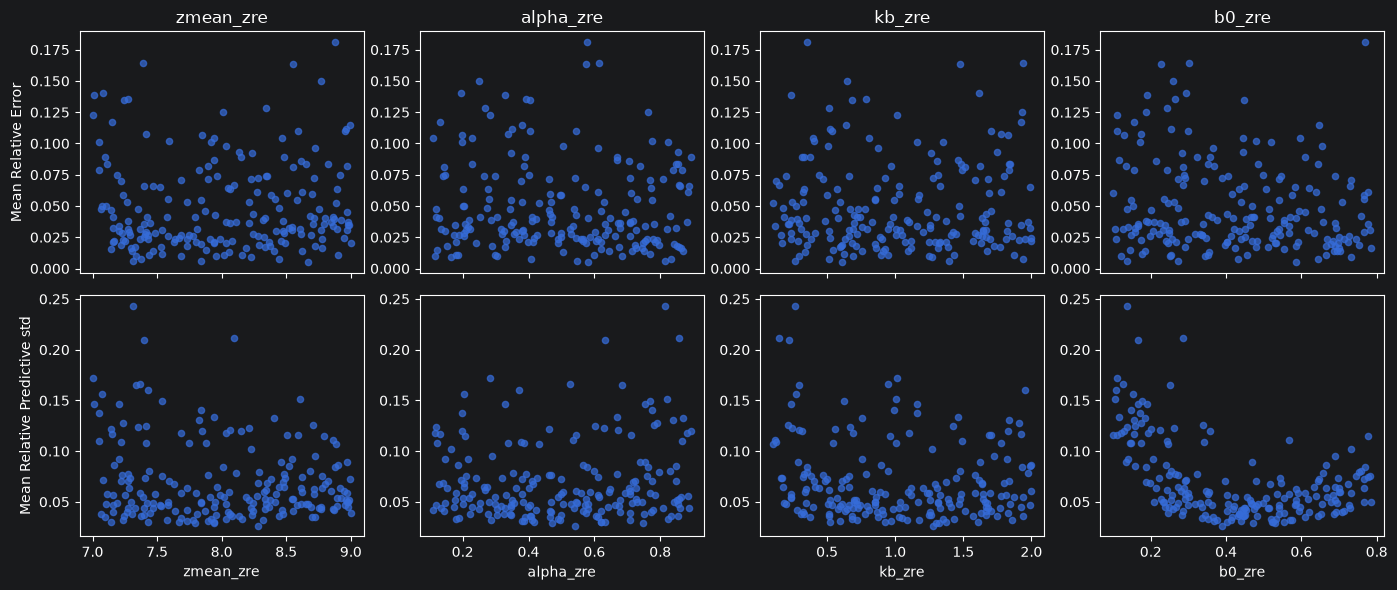

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex="col")

for col in range(4):
    # Relative Error
    axes[0, col].scatter(X_test[:, col], sim_mean_rel_error, s=20, alpha=0.7)
    axes[0, col].set_title(param_names[col])

    # Predictive Uncertainty
    axes[1, col].scatter(X_test[:, col], sim_mean_rel_std, s=20, alpha=0.7)
    axes[1, col].set_xlabel(param_names[col])

axes[0, 0].set_ylabel("Mean Relative Error")
axes[1, 0].set_ylabel("Mean Relative Predictive std")

plt.tight_layout()
plt.savefig(fig_path + "error-uncertainty-vs-param", dpi=150, bbox_inches="tight")
plt.show()

# Correlation Between $\sigma$ and Error
---

In [9]:
res_s, pvalue_s = spearmanr(sim_mean_rel_std, sim_mean_rel_error)
res_p, pvalue_p = pearsonr(sim_mean_rel_std, sim_mean_rel_error)

print(f"Spearman Correlation:\t{res_s:.3f}, p-value: {pvalue_s:.3f}")
print(f"Pearson Correlation:\t{res_p:.3f}, p-value: {pvalue_p:.3f}")

Spearman Correlation:	0.041, p-value: 0.565
Pearson Correlation:	0.041, p-value: 0.562


# Correlation Between Nearest Neighbors and  Error
---

Spearman:	0.271, p-value: 0.000102
Pearson:	0.192, p-value: 0.00659


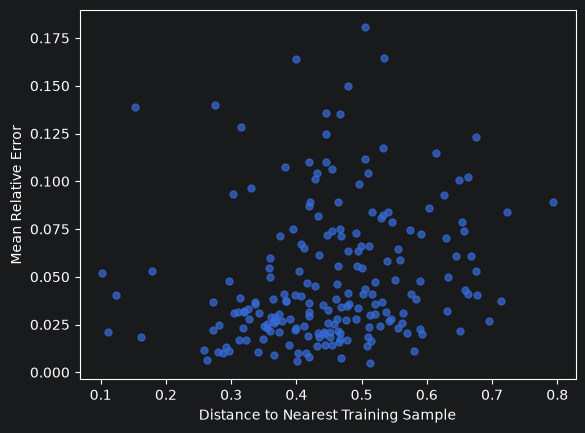

In [10]:
tree = cKDTree(X_train_norm)
nearest_dist, nearest_train_pos = tree.query(X_test_norm, k=1)
nearest_global_idx = train_idx[nearest_train_pos]

rho_s, p_s = spearmanr(nearest_dist, sim_mean_rel_error)
rho_p, p_p = pearsonr(nearest_dist, sim_mean_rel_error)

print(f"Spearman:\t{rho_s:.3f}, p-value: {p_s:.3g}")
print(f"Pearson:\t{rho_p:.3f}, p-value: {p_p:.3g}")

plt.scatter(nearest_dist, sim_mean_rel_error, s=25, alpha=0.7)
plt.xlabel("Distance to Nearest Training Sample")
plt.ylabel("Mean Relative Error")
plt.savefig(fig_path+'distance-vs-error', dpi=150, bbox_inches='tight')
plt.show()

# Correlation Between Nearest Neighbors and $\sigma$
---

Spearman:	-0.110, p-value: 0.119
Pearson:	-0.110, p-value: 0.121


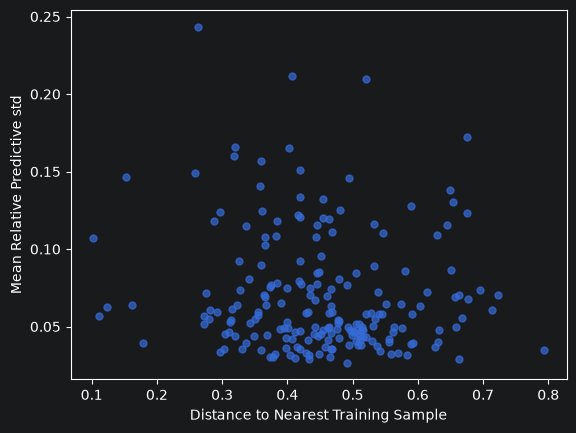

In [11]:
tree = cKDTree(X_train_norm)
nearest_dist, nearest_train_pos = tree.query(X_test_norm, k=1)
nearest_global_idx = train_idx[nearest_train_pos]

rho_s, p_s = spearmanr(nearest_dist, sim_mean_rel_std)
rho_p, p_p = pearsonr(nearest_dist, sim_mean_rel_std)

print(f"Spearman:\t{rho_s:.3f}, p-value: {p_s:.3g}")
print(f"Pearson:\t{rho_p:.3f}, p-value: {p_p:.3g}")

plt.scatter(nearest_dist, sim_mean_rel_std, s=25, alpha=0.7)
plt.xlabel("Distance to Nearest Training Sample")
plt.ylabel("Mean Relative Predictive std")
plt.savefig(fig_path+'distance-vs-uncertainty', dpi=150, bbox_inches='tight')
plt.show()

# Inspect Overconfident Cases
---

## Compute Pulls

In [12]:
pulls = (pred_mean - np.exp(Y_test)) / pred_std
abs_pulls = np.abs(pred_mean - np.exp(Y_test)) / pred_std

mean_abs_pulls = np.mean(abs_pulls, axis=1)
mean_abs_pulls_idx = np.argsort(mean_abs_pulls)[::-1]

print(mean_abs_pulls_idx)

[149  50 105  12 174 193 137  11 168  91 171  29  30  92 156 125  80 103
 169 130  49  40 161 151  45 158  98 191 131 199  83  86 182  24 172 144
  37 153 184 135 129  69 134  22 114  87 148 123 107   3  52  93  10  36
  59  96  18  58 185 170 132 165 181 197 159  65 194 166  16 150 108 116
  44  32 112 117  73   9  54 139  34 190 187  47 154   2  60 178 157 147
 167  79  62 120  43  89  26   5 146  55  23  94  90   0 179 186 141  74
 121  27 128  39  72 122  75  78 102 110 113 173 152 162  17  99   8  68
 109  48  57 100  46  38 160 140  70 176 142  77  71  28 180  88  13  66
 155  95 119  64 175 195 177 198  31 127  76 145  61 124 104  67 101  21
  53  63 106  19 163  84 136 126  20 192  82  15   7 118 115   6   1  25
  81  51  97  56 111 183 188  35 133 189  41   4  42 138  33 164 196  14
  85 143]


In [13]:
for i in range(3):
    idx = mean_abs_pulls_idx[i]
    print(f"Simulation {idx}")
    print(f"\tParameters: {X_test[idx]}")
    print(f"\tPulls: {pulls[idx]}")
    print(f"\t|Pulls|: {abs_pulls[idx]}")
    print(f"\tMean |Pull|: {mean_abs_pulls[idx]}")
    print(f"\tMean Relative Error: {sim_mean_rel_error[idx]}")

Simulation 149
	Parameters: [8.77111    0.24975798 0.64475316 0.25997373]
	Pulls: [-5.436974  -5.0416174 -4.3004694 -3.2899258 -2.9220607]
	|Pulls|: [5.436974  5.0416174 4.3004694 3.2899258 2.9220607]
	Mean |Pull|: 4.198209285736084
	Mean Relative Error: 0.1497865617275238
Simulation 50
	Parameters: [8.555149  0.5734222 1.4763184 0.2265809]
	Pulls: [-4.734939  -4.6253095 -3.990558  -3.154722  -2.5493171]
	|Pulls|: [4.734939  4.6253095 3.990558  3.154722  2.5493171]
	Mean |Pull|: 3.8109688758850098
	Mean Relative Error: 0.1638968288898468
Simulation 105
	Parameters: [7.388383   0.6152391  1.9390563  0.30245164]
	Pulls: [-3.3666997 -3.7187707 -3.6020658 -3.6957731 -3.6896632]
	|Pulls|: [3.3666997 3.7187707 3.6020658 3.6957731 3.6896632]
	Mean |Pull|: 3.6145946979522705
	Mean Relative Error: 0.16447141766548157


## Most Overconfident

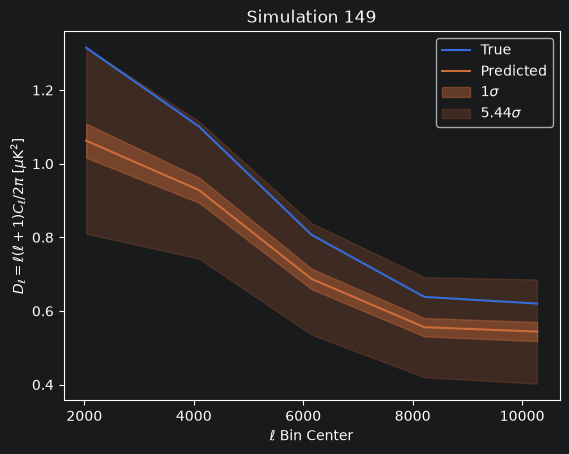

In [14]:
idx = mean_abs_pulls_idx[0]

# Plot true data
plt.plot(ell, np.exp(Y_test[idx]), label="True")
plt.plot(ell, pred_mean[idx], label="Predicted")
plt.fill_between(ell, pred_mean[idx] - pred_std[idx], pred_mean[idx] + pred_std[idx], alpha=0.4, color="C1", label=r"1$\sigma$")
plt.fill_between(ell, pred_mean[idx] - (pred_std[idx] * np.max(abs_pulls[idx])), pred_mean[idx] + (pred_std[idx] *  np.max(abs_pulls[idx])), alpha=0.2, color="C1", label=rf"{np.max(abs_pulls[idx]):.2f}$\sigma$")

plt.title(f"Simulation {idx}")
plt.xlabel(r"$\ell$ Bin Center")
plt.ylabel(r"$D_\ell = \ell(\ell + 1)C_\ell / 2\pi$ [$\mu \mathrm{K}^2$]")
plt.legend()
plt.savefig(fig_path+'most-overconfident', dpi=150, bbox_inches='tight')
plt.show()

# Empirical Coverage
---

In [15]:
one_sigma = np.mean(abs_pulls < 1)
two_sigma = np.mean(abs_pulls < 2)
three_sigma = np.mean(abs_pulls < 3)

print(f"1 sigma: {one_sigma:.2f} \t Gaussian: 0.6826")
print(f"2 sigma: {two_sigma:.2f} \t Gaussian: 0.9545")
print(f"3 sigma: {three_sigma:.2f} \t Gaussian: 0.9973")

1 sigma: 0.67 	 Gaussian: 0.6826
2 sigma: 0.89 	 Gaussian: 0.9545
3 sigma: 0.96 	 Gaussian: 0.9973


# Reliability
---

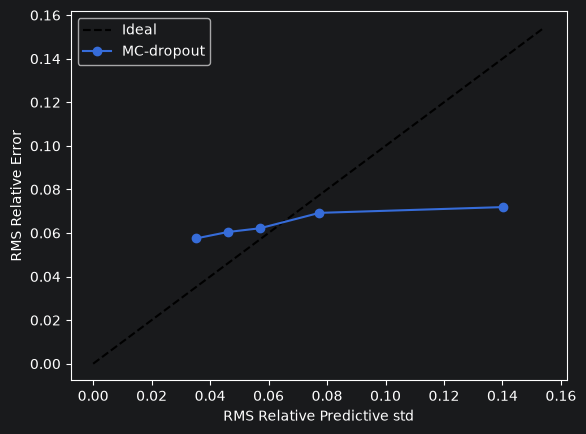

In [16]:
groups = np.array_split(np.argsort(sim_mean_rel_std), 5)
group_std = [np.sqrt(np.mean(rel_std[g] ** 2)) for g in groups]
group_err = [np.sqrt(np.mean(rel_error[g] ** 2)) for g in groups]

lim = 1.1 * max(max(group_std), max(group_err))
plt.plot([0, lim], [0, lim], "k--", label="Ideal")
plt.plot(group_std, group_err, "o-", label="MC-dropout")
plt.xlabel("RMS Relative Predictive std")
plt.ylabel("RMS Relative Error")
plt.legend()
plt.savefig(fig_path + "reliability", dpi=150, bbox_inches="tight")
plt.show()